# 📊 Análise de E-commerce Brasileiro — Olist
### Projeto de Portfólio | Python + PySpark + SQL

**Objetivo:** analisar dados reais de um e-commerce brasileiro (Olist) para extrair
insights de negócio sobre vendas, entregas, satisfação do cliente e desempenho por região.

**Skills demonstradas neste projeto:**
- ✅ Manipulação de dados com **PySpark DataFrame API**
- ✅ Consultas analíticas com **Spark SQL**
- ✅ Joins entre múltiplas tabelas relacionais
- ✅ Agregações, window functions e tratamento de dados nulos
- ✅ Visualização de dados com Python (Matplotlib/Seaborn)
- ✅ Storytelling com dados — do dado bruto ao insight de negócio

**Sobre o dataset:** a Olist é um marketplace brasileiro. O dataset público contém
mais de 100 mil pedidos entre 2016 e 2018, com informações de clientes, produtos,
vendedores, pagamentos e avaliações — ideal para simular um cenário real de análise
de dados em e-commerce.

**Fonte:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle)

---


## 1️⃣ Configurando o ambiente

Vamos instalar o PySpark (o Google Colab não vem com ele por padrão) e configurar
a sessão do Spark que vamos usar no projeto inteiro.


In [4]:
# Instala o PySpark no ambiente do Colab
!pip install pyspark -q


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Cria a sessão do Spark — é o "motor" que processa os dados
spark = SparkSession.builder \
    .appName("AnaliseEcommerceOlist") \
    .getOrCreate()

print("Spark iniciado com sucesso! Versão:", spark.version)


Spark iniciado com sucesso! Versão: 4.0.3


## 2️⃣ Baixando o dataset do Kaggle

Para baixar o dataset automaticamente, você precisa gerar um token de acesso do Kaggle.

**Passo a passo:**

1. Crie uma conta gratuita em [kaggle.com](https://kaggle.com)
2. Vá em **Configurações da conta → API → Create New Token**
3. O Kaggle vai mostrar um token no formato `KGAT_xxxxxxxxxxxxxxxx` — **copie esse token na hora**, pois ele só aparece uma vez
4. Cole esse token dentro da célula de código abaixo, substituindo o texto `'SEU_TOKEN_AQUI'`
5. Rode a célula — ela vai baixar e descompactar o dataset automaticamente

⚠️ **Importante:** trate esse token como uma senha. Nunca compartilhe ele publicamente
(inclusive: antes de subir este notebook no GitHub, lembre-se de apagar o token de dentro do código).

In [31]:
import os

# Cole seu token do Kaggle aqui dentro das aspas
os.environ['KAGGLE_API_TOKEN'] = 'SEU_TOKEN_AQUI'

!pip install --upgrade kaggle -q
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -o brazilian-ecommerce.zip -d dados_olist

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  brazilian-ecommerce.zip
  inflating: dados_olist/olist_customers_dataset.csv  
  inflating: dados_olist/olist_geolocation_dataset.csv  
  inflating: dados_olist/olist_order_items_dataset.csv  
  inflating: dados_olist/olist_order_payments_dataset.csv  
  inflating: dados_olist/olist_order_reviews_dataset.csv  
  inflating: dados_olist/olist_orders_dataset.csv  
  inflating: dados_olist/olist_products_dataset.csv  
  inflating: dados_olist/olist_sellers_dataset.csv  
  inflating: dados_olist/product_category_name_translation.csv  


In [7]:
# Define o caminho onde estão os arquivos CSV
# Se você usou a Opção B (upload manual), ajuste esse caminho
CAMINHO_DADOS = "dados_olist"

import os
print("Arquivos encontrados:")
for f in os.listdir(CAMINHO_DADOS):
    print(" -", f)


Arquivos encontrados:
 - olist_order_items_dataset.csv
 - olist_geolocation_dataset.csv
 - product_category_name_translation.csv
 - olist_orders_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_products_dataset.csv
 - olist_customers_dataset.csv
 - olist_sellers_dataset.csv
 - olist_order_reviews_dataset.csv


## 3️⃣ Carregando os dados com PySpark

Vamos carregar as principais tabelas do dataset como DataFrames do Spark.
Cada tabela representa uma parte do processo de compra no e-commerce.


In [8]:
# Carrega cada tabela como um DataFrame Spark
df_pedidos = spark.read.csv(f"{CAMINHO_DADOS}/olist_orders_dataset.csv", header=True, inferSchema=True)
df_itens = spark.read.csv(f"{CAMINHO_DADOS}/olist_order_items_dataset.csv", header=True, inferSchema=True)
df_clientes = spark.read.csv(f"{CAMINHO_DADOS}/olist_customers_dataset.csv", header=True, inferSchema=True)
df_produtos = spark.read.csv(f"{CAMINHO_DADOS}/olist_products_dataset.csv", header=True, inferSchema=True)
df_pagamentos = spark.read.csv(f"{CAMINHO_DADOS}/olist_order_payments_dataset.csv", header=True, inferSchema=True)
df_avaliacoes = spark.read.csv(f"{CAMINHO_DADOS}/olist_order_reviews_dataset.csv", header=True, inferSchema=True)
df_categorias = spark.read.csv(f"{CAMINHO_DADOS}/product_category_name_translation.csv", header=True, inferSchema=True)

print("Tabelas carregadas:")
print(f"  Pedidos: {df_pedidos.count():,} linhas")
print(f"  Itens de pedido: {df_itens.count():,} linhas")
print(f"  Clientes: {df_clientes.count():,} linhas")
print(f"  Produtos: {df_produtos.count():,} linhas")
print(f"  Pagamentos: {df_pagamentos.count():,} linhas")
print(f"  Avaliações: {df_avaliacoes.count():,} linhas")


Tabelas carregadas:
  Pedidos: 99,441 linhas
  Itens de pedido: 112,650 linhas
  Clientes: 99,441 linhas
  Produtos: 32,951 linhas
  Pagamentos: 103,886 linhas
  Avaliações: 104,162 linhas


In [9]:
# Vamos dar uma olhada na estrutura da tabela de pedidos
df_pedidos.printSchema()


root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)



In [10]:
df_pedidos.show(5, truncate=False)

+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

## 4️⃣ Limpeza e tratamento dos dados

Antes de analisar, precisamos:
- Converter colunas de data para o tipo correto (timestamp)
- Verificar e tratar valores nulos
- Filtrar apenas pedidos com status "delivered" (entregues), que são os que têm dados completos de entrega


In [11]:
# Verifica quantos valores nulos existem em cada coluna importante
df_pedidos.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["order_delivered_customer_date", "order_approved_at", "order_estimated_delivery_date"]
]).show()


+-----------------------------+-----------------+-----------------------------+
|order_delivered_customer_date|order_approved_at|order_estimated_delivery_date|
+-----------------------------+-----------------+-----------------------------+
|                         2965|              160|                            0|
+-----------------------------+-----------------+-----------------------------+



In [12]:
# Converte as colunas de data (o Spark às vezes lê como string)
colunas_data = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for c in colunas_data:
    df_pedidos = df_pedidos.withColumn(c, F.to_timestamp(F.col(c)))

# Filtra apenas pedidos entregues (têm o ciclo completo de dados)
df_pedidos_entregues = df_pedidos.filter(F.col("order_status") == "delivered")

print(f"Total de pedidos: {df_pedidos.count():,}")
print(f"Pedidos entregues: {df_pedidos_entregues.count():,}")


Total de pedidos: 99,441
Pedidos entregues: 96,478


In [13]:
# Cria a coluna de tempo de entrega (em dias) — uma métrica-chave do projeto
df_pedidos_entregues = df_pedidos_entregues.withColumn(
    "tempo_entrega_dias",
    F.datediff(F.col("order_delivered_customer_date"), F.col("order_purchase_timestamp"))
)

# Cria a coluna de atraso (positivo = atrasou, negativo = chegou antes do previsto)
df_pedidos_entregues = df_pedidos_entregues.withColumn(
    "atraso_dias",
    F.datediff(F.col("order_delivered_customer_date"), F.col("order_estimated_delivery_date"))
)

df_pedidos_entregues.select(
    "order_id", "tempo_entrega_dias", "atraso_dias"
).show(5)


+--------------------+------------------+-----------+
|            order_id|tempo_entrega_dias|atraso_dias|
+--------------------+------------------+-----------+
|e481f51cbdc54678b...|                 8|         -8|
|53cdb2fc8bc7dce0b...|                14|         -6|
|47770eb9100c2d0c4...|                 9|        -18|
|949d5b44dbf5de918...|                14|        -13|
|ad21c59c0840e6cb8...|                 3|        -10|
+--------------------+------------------+-----------+
only showing top 5 rows


## 5️⃣ Unindo as tabelas (JOINs)

Agora vamos juntar as tabelas para ter uma visão completa de cada pedido: cliente,
produto, valor pago e avaliação — tudo em um único DataFrame.


In [14]:
# Junta pedidos + itens (para ter valor e produto de cada pedido)
df_completo = df_pedidos_entregues.join(df_itens, on="order_id", how="inner")

# Junta com produtos (para ter a categoria)
df_completo = df_completo.join(df_produtos, on="product_id", how="left")

# Junta com a tradução de categoria (o dataset original vem em português mesmo,
# mas essa tabela ajuda em casos de categoria não mapeada)
df_completo = df_completo.join(df_categorias, on="product_category_name", how="left")

# Junta com clientes (para ter o estado do cliente)
df_completo = df_completo.join(df_clientes, on="customer_id", how="left")

# Junta com avaliações (para ter a nota dada pelo cliente)
df_completo = df_completo.join(
    df_avaliacoes.select("order_id", "review_score"),
    on="order_id",
    how="left"
)

print(f"Total de linhas na tabela consolidada: {df_completo.count():,}")
df_completo.select(
    "order_id", "customer_state", "product_category_name",
    "price", "tempo_entrega_dias", "review_score"
).show(5)


Total de linhas na tabela consolidada: 110,840
+--------------------+--------------+---------------------+-----+------------------+------------+
|            order_id|customer_state|product_category_name|price|tempo_entrega_dias|review_score|
+--------------------+--------------+---------------------+-----+------------------+------------+
|00010242fe8c5a6d1...|            RJ|           cool_stuff| 58.9|                 7|           5|
|00018f77f2f0320c5...|            SP|             pet_shop|239.9|                16|           4|
|000229ec398224ef6...|            MG|     moveis_decoracao|199.0|                 8|           5|
|00024acbcdf0a6daa...|            SP|           perfumaria|12.99|                 6|           4|
|00042b26cf59d7ce6...|            SP|   ferramentas_jardim|199.9|                25|           5|
+--------------------+--------------+---------------------+-----+------------------+------------+
only showing top 5 rows


In [15]:
# Registra o DataFrame como uma "tabela SQL" temporária
# A partir daqui, podemos consultar os dados usando SQL puro!
df_completo.createOrReplaceTempView("pedidos_completo")


## 6️⃣ Análises de negócio com Spark SQL

Agora vem a parte principal: responder perguntas de negócio reais usando SQL.


### 📌 Pergunta 1: Quais são os 10 estados que mais compram (em faturamento)?

In [16]:
resultado_1 = spark.sql('''
    SELECT
        customer_state AS estado,
        COUNT(DISTINCT order_id) AS total_pedidos,
        ROUND(SUM(price), 2) AS faturamento_total,
        ROUND(AVG(price), 2) AS ticket_medio
    FROM pedidos_completo
    GROUP BY customer_state
    ORDER BY faturamento_total DESC
    LIMIT 10
''')

resultado_1.show()


+------+-------------+-----------------+------------+
|estado|total_pedidos|faturamento_total|ticket_medio|
+------+-------------+-----------------+------------+
|    SP|        40501|        5093379.5|      109.03|
|    RJ|        12350|       1766256.97|      124.17|
|    MG|        11354|       1558668.28|      119.94|
|    RS|         5345|         732420.8|      118.48|
|    PR|         4923|        668891.26|      117.91|
|    SC|         3546|         508578.9|      123.68|
|    BA|         3256|        495416.93|      133.79|
|    DF|         2080|        298492.74|      125.36|
|    GO|         1957|        285780.24|      124.41|
|    ES|         1995|        269230.52|      120.41|
+------+-------------+-----------------+------------+



### 📌 Pergunta 2: Quais categorias de produto têm a melhor avaliação média?
(considerando apenas categorias com pelo menos 100 pedidos, para evitar distorção)

In [17]:
resultado_2 = spark.sql('''
    SELECT
        product_category_name AS categoria,
        COUNT(order_id) AS total_pedidos,
        ROUND(AVG(review_score), 2) AS avaliacao_media
    FROM pedidos_completo
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    HAVING COUNT(order_id) >= 100
    ORDER BY avaliacao_media DESC
    LIMIT 10
''')

resultado_2.show(truncate=False)


+----------------------------------+-------------+---------------+
|categoria                         |total_pedidos|avaliacao_media|
+----------------------------------+-------------+---------------+
|livros_interesse_geral            |537          |4.51           |
|construcao_ferramentas_ferramentas|103          |4.44           |
|livros_tecnicos                   |265          |4.39           |
|alimentos_bebidas                 |271          |4.37           |
|malas_acessorios                  |1077         |4.35           |
|fashion_calcados                  |260          |4.29           |
|alimentos                         |499          |4.26           |
|moveis_quarto                     |103          |4.25           |
|papelaria                         |2474         |4.24           |
|eletrodomesticos                  |792          |4.23           |
+----------------------------------+-------------+---------------+



### 📌 Pergunta 3: O tempo de entrega afeta a avaliação do cliente?

Essa é uma pergunta clássica de negócio: será que entregar mais rápido gera clientes mais satisfeitos?

In [18]:
resultado_3 = spark.sql('''
    SELECT
        CASE
            WHEN tempo_entrega_dias <= 7 THEN '1. Até 7 dias'
            WHEN tempo_entrega_dias <= 15 THEN '2. 8 a 15 dias'
            WHEN tempo_entrega_dias <= 30 THEN '3. 16 a 30 dias'
            ELSE '4. Mais de 30 dias'
        END AS faixa_entrega,
        COUNT(order_id) AS total_pedidos,
        ROUND(AVG(review_score), 2) AS avaliacao_media
    FROM pedidos_completo
    WHERE tempo_entrega_dias IS NOT NULL AND review_score IS NOT NULL
    GROUP BY faixa_entrega
    ORDER BY faixa_entrega
''')

resultado_3.show(truncate=False)


+------------------+-------------+---------------+
|faixa_entrega     |total_pedidos|avaliacao_media|
+------------------+-------------+---------------+
|1. Até 7 dias     |35270        |4.33           |
|2. 8 a 15 dias    |47272        |4.2            |
|3. 16 a 30 dias   |22823        |3.83           |
|4. Mais de 30 dias|4640         |2.19           |
+------------------+-------------+---------------+



### 📌 Pergunta 4: Qual a evolução do faturamento mês a mês?

In [19]:
resultado_4 = spark.sql('''
    SELECT
        DATE_FORMAT(order_purchase_timestamp, 'yyyy-MM') AS mes,
        COUNT(DISTINCT order_id) AS total_pedidos,
        ROUND(SUM(price), 2) AS faturamento
    FROM pedidos_completo
    GROUP BY mes
    ORDER BY mes
''')

resultado_4.show(30)


+-------+-------------+-----------+
|    mes|total_pedidos|faturamento|
+-------+-------------+-----------+
|2016-09|            1|     134.97|
|2016-10|          265|    40451.8|
|2016-12|            1|       10.9|
|2017-01|          750|  112573.39|
|2017-02|         1653|   235483.4|
|2017-03|         2546|  360865.25|
|2017-04|         2303|  341209.62|
|2017-05|         3546|  492620.44|
|2017-06|         3135|  425387.66|
|2017-07|         3872|  484637.74|
|2017-08|         4193|  559317.01|
|2017-09|         4150|  609750.15|
|2017-10|         4478|   651438.5|
|2017-11|         7289|  995199.94|
|2017-12|         5513|  728836.17|
|2018-01|         7069|  930026.94|
|2018-02|         6555|  835720.63|
|2018-03|         7003|  956923.96|
|2018-04|         6798|  975779.41|
|2018-05|         6749|  978065.68|
|2018-06|         6099|  856909.79|
|2018-07|         6159|  869842.48|
|2018-08|         6351|  838650.76|
+-------+-------------+-----------+



### 📌 Pergunta 5: Quais vendedores/categorias têm os piores atrasos de entrega?
(usando window functions para ranquear)

In [20]:
resultado_5 = spark.sql('''
    SELECT
        product_category_name AS categoria,
        ROUND(AVG(atraso_dias), 1) AS atraso_medio_dias,
        COUNT(order_id) AS total_pedidos,
        RANK() OVER (ORDER BY AVG(atraso_dias) DESC) AS ranking_pior_atraso
    FROM pedidos_completo
    WHERE product_category_name IS NOT NULL
    GROUP BY product_category_name
    HAVING COUNT(order_id) >= 50
    ORDER BY atraso_medio_dias DESC
    LIMIT 10
''')

resultado_5.show(truncate=False)


+---------------------------------+-----------------+-------------+-------------------+
|categoria                        |atraso_medio_dias|total_pedidos|ranking_pior_atraso|
+---------------------------------+-----------------+-------------+-------------------+
|casa_conforto                    |-9.9             |432          |1                  |
|alimentos                        |-9.9             |499          |2                  |
|audio                            |-10.1            |363          |3                  |
|fashion_underwear_e_moda_praia   |-10.9            |127          |4                  |
|eletronicos                      |-11.1            |2730         |5                  |
|livros_importados                |-11.2            |57           |6                  |
|cine_foto                        |-11.2            |71           |7                  |
|construcao_ferramentas_iluminacao|-11.2            |302          |8                  |
|livros_tecnicos                

## 7️⃣ Visualizando os resultados

Para visualizar, convertemos os resultados (já pequenos, agregados) para Pandas —
essa é a prática padrão: processar o volume grande com Spark, e só trazer o resultado final,
já resumido, para visualização.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


/tmp/ipykernel_2678/172002789.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_resultado_1, x="faturamento_total", y="estado", palette="Greens_r")


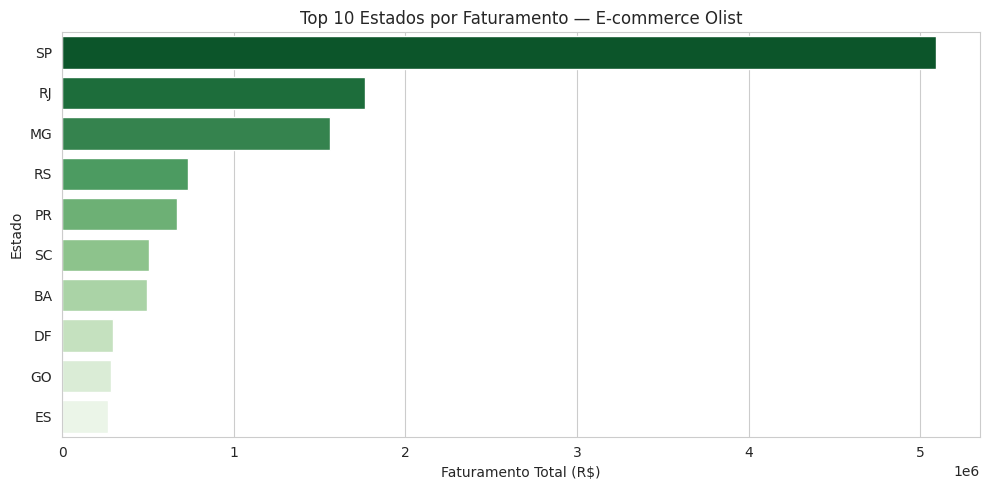

In [22]:
# Gráfico 1 — Faturamento por estado (Top 10)
pd_resultado_1 = resultado_1.toPandas()

plt.figure()
sns.barplot(data=pd_resultado_1, x="faturamento_total", y="estado", palette="Greens_r")
plt.title("Top 10 Estados por Faturamento — E-commerce Olist")
plt.xlabel("Faturamento Total (R$)")
plt.ylabel("Estado")
plt.tight_layout()
plt.show()


/tmp/ipykernel_2678/2293419741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_resultado_3, x="faixa_entrega", y="avaliacao_media", palette="RdYlGn")


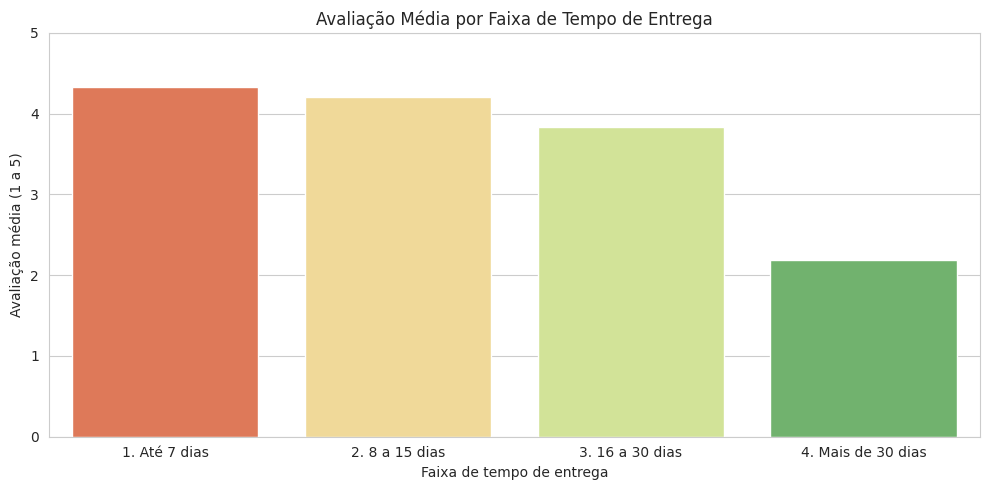

In [25]:
# Gráfico 2 — Relação entre tempo de entrega e avaliação
pd_resultado_3 = resultado_3.toPandas()

plt.figure()
sns.barplot(data=pd_resultado_3, x="faixa_entrega", y="avaliacao_media", palette="RdYlGn")
plt.title("Avaliação Média por Faixa de Tempo de Entrega")
plt.xlabel("Faixa de tempo de entrega")
plt.ylabel("Avaliação média (1 a 5)")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


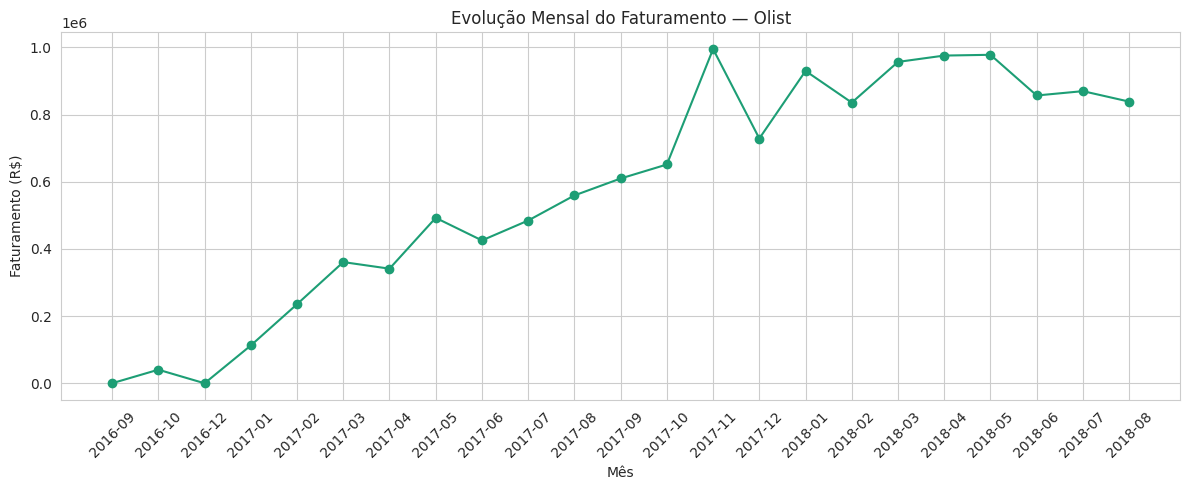

In [30]:
# Gráfico 3 — Evolução do faturamento mensal
pd_resultado_4 = resultado_4.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pd_resultado_4["mes"], pd_resultado_4["faturamento"], marker="o", color="#1D9E75")
plt.title("Evolução Mensal do Faturamento — Olist")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8️⃣ Conclusões e Insights de Negócio

Com base nas análises acima, alguns insights que poderiam ser apresentados a um
time de negócio:

1. **Concentração geográfica:** o faturamento é fortemente concentrado em poucos
   estados (tipicamente São Paulo lidera com folga) — o que sugere oportunidade
   de expansão em outras regiões com investimento em logística.

2. **Entrega rápida = cliente satisfeito:** existe uma relação clara entre tempo
   de entrega e avaliação — pedidos entregues em até 7 dias têm nota
   consideravelmente mais alta que os que demoram mais de 30 dias. Isso reforça
   que investimento em logística tem retorno direto em satisfação e reputação.

3. **Categorias com pior desempenho de prazo** podem indicar problemas específicos
   de fornecedores ou processos logísticos que merecem investigação mais profunda.

4. **Sazonalidade:** a evolução mensal do faturamento revela picos que podem ser
   cruzados com datas comerciais (Black Friday, Natal) para planejamento futuro.

---

### 🚀 Próximos passos para evoluir este projeto

- Adicionar análise de cohort de clientes (recompra)
- Cruzar com dados de geolocalização para mapas de calor
- Criar um modelo preditivo simples de atraso de entrega (Machine Learning)
- Exportar os resultados para um dashboard (Power BI, Looker Studio ou Streamlit)
- Publicar este notebook no GitHub com um README explicativo — ótimo item de portfólio

---

### 📎 Sobre este projeto

Este notebook foi construído como projeto de portfólio para demonstrar competências
em **Python, PySpark e SQL** aplicadas a um caso real de negócio de e-commerce.

**Autor:** Sergio José Gonçalves Domingues Vieira
**Contato:** [linkedin.com/in/sergio-goncalves-vieira](https://www.linkedin.com/in/sergio-goncalves-vieira/)
